# 04a — Multiple Choice (Q17, Q18, Q20, Q21) and Q16 (anomaly)

**Discovered during inspection**: Q17, Q18, Q20, Q21 were not open questions, but multiple-choice with checkboxes. Responses stored as text contain the labels of marked options, separated by commas. **Q16 is anomalous** — 30 out of 32 PT responses are literally identical, suggesting a pre-selected default option most respondents did not change.

This notebook:
1. Parses each response into canonical options
2. Reports % marked per option (with Wilson 95% CI)
3. Generates consolidated figures for Section 4 (implementation)
4. Treats Q16 as a meta-finding — reports the anomaly as evidence about the instrument

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

sys.path.insert(0, str(Path.cwd()))
import utils as U

U.setup_matplotlib()
TABLES = U.DATA_PROC / "tables"
df = U.load_anonymized()
print(f"N={len(df)}")

N=41


## 1. Canonical option definitions per question

Extracted by inspecting responses. Each list preserves the order in which it appears in the Forms (important for visual ordering).

In [2]:
# Each option maps to a list of accepted substrings (PT + EN). `parse_checkboxes`
# ORs all aliases together so respondents from the international form are accepted
# without translation.

Q17_OPTIONS = {  # incorporation_open
    "q17_initial_eval": [
        "Avaliação inicial durante a coleta e preparação de dados",
        "Initial assessment during data collection and preparation",
    ],
    "q17_continuous_mon": [
        "Monitoramento contínuo durante todo o ciclo de vida do modelo",
        "Continuous monitoring throughout the model's life cycle",
    ],
    "q17_test_sets": [
        "Conjuntos de testes são aplicados para validar a consistência, completude e precisão dos dados antes de serem usados no treinamento.",
        "Test sets are applied to validate the consistency, completeness and accuracy of the data before it is used for training.",
    ],
    "q17_no_strategy": [
        "Não existe uma estratégia formal para assegurar a qualidade dos dados durante o desenvolvimento.",
        "There is no formal strategy to ensure data quality during development.",
    ],
}
Q17_LABELS = {
    "q17_initial_eval": "Initial assessment in collection/preparation",
    "q17_continuous_mon": "Continuous monitoring across lifecycle",
    "q17_test_sets": "Test sets before training",
    "q17_no_strategy": "No formal strategy",
}

Q18_OPTIONS = {  # measurement_open
    "q18_ab_tests": ["Testes A/B", "A/B testing"],
    "q18_perf_metrics": [
        "Análise de métricas de performance (ex.: precisão, recall)",
        "Analysis of performance metrics (e.g. precision, recall)",
    ],
    "q18_manual_review": ["Revisão manual dos resultados", "Manual review of results"],
}
Q18_LABELS = {
    "q18_ab_tests": "A/B testing",
    "q18_perf_metrics": "Performance metrics",
    "q18_manual_review": "Manual review of results",
}

Q20_OPTIONS = {  # documentation_open
    "q20_structured_text": ["Linguagem estruturada (texto)", "Structured language (text)"],
    "q20_pm_tools": [
        "Ferramentas de Gerenciamento de Projetos (Jira, Trello ou Asana)",
        "Project management tools (Jira, Trello or Asana)",
    ],
    "q20_central_docs": [
        "Documentação Centralizada (Sistemas como Confluence, Google Docs ou Notion)",
        "Centralized documentation (systems such as Confluence, Google Docs or Notion)",
    ],
    "q20_alignment_meet": ["Reuniões de Alinhamento", "Alignment meetings"],
    "q20_periodic_reports": ["Relatórios Periódicos", "Periodic reports"],
}
Q20_LABELS = {
    "q20_structured_text": "Structured language (text)",
    "q20_pm_tools": "Project management tools (Jira/etc.)",
    "q20_central_docs": "Centralized documentation (Confluence/etc.)",
    "q20_alignment_meet": "Alignment meetings",
    "q20_periodic_reports": "Periodic reports",
}

Q21_OPTIONS = {  # challenges_open
    "q21_inconsistency": [
        "Inconsistência entre diferentes fontes de dados",
        "Inconsistency between different data sources",
    ],
    "q21_incompleteness": ["Dados incompletos ou ausentes", "Incomplete or missing data"],
    "q21_no_standard": [
        "Falta de padronização nos formatos de dados",
        "Lack of standardization in data formats",
    ],
    "q21_outdated": ["Dados desatualizados ou não confiáveis", "Outdated or unreliable data"],
    "q21_collection_errors": [
        "Erros introduzidos durante a coleta e processamento",
        "Errors introduced during collection and processing",
    ],
    "q21_traceability": [
        "Dificuldade na rastreabilidade e versionamento dos dados",
        "Difficulty in data traceability and versioning",
    ],
    "q21_no_tools": [
        "Falta de ferramentas adequadas para validação da qualidade dos dados",
        "Lack of adequate tools for validating data quality",
    ],
}
Q21_LABELS = {
    "q21_inconsistency": "Inconsistency across sources",
    "q21_incompleteness": "Incomplete/missing data",
    "q21_no_standard": "Lack of format standardization",
    "q21_outdated": "Outdated/unreliable data",
    "q21_collection_errors": "Errors in collection and processing",
    "q21_traceability": "Difficulty in traceability/versioning",
    "q21_no_tools": "Lack of validation tools",
}

## 2. Parser — converts free text into binary columns

In [3]:
rng = np.random.default_rng(42)

def _boot_ci(
    values: np.ndarray,
    threshold: int = 4,
    n_bootstrap: int = 2000,
    ci_level: float = 0.95,
) -> tuple[float, float]:
    """Percentile bootstrap CI for the proportion of values >= threshold.

    Parameters
    ----------
    values      : 1-D array of observed values (int or bool/0-1)
    threshold   : values >= threshold count as "success" (default 4, Likert top-box)
                  For binary 0/1 arrays pass threshold=1.
    n_bootstrap : number of bootstrap resamples (default 2000)
    ci_level    : confidence level (default 0.95 → 95% CI)

    Returns
    -------
    (lo, hi) proportions in [0, 1]
    """
    values = np.asarray(values)
    n = len(values)
    if n == 0:
        return float("nan"), float("nan")

    alpha = 1 - ci_level
    boot_indices = rng.integers(0, n, size=(n_bootstrap, n))
    boot_props = np.mean(values[boot_indices] >= threshold, axis=1)
    lo = np.percentile(boot_props, 100 * alpha / 2)
    hi = np.percentile(boot_props, 100 * (1 - alpha / 2))
    return lo, hi

In [4]:
def parse_checkboxes(series: pd.Series, options: dict) -> tuple[pd.DataFrame, pd.Series]:
    """For each response, marks True if *any* alias (PT/EN) of the option appears
    as a substring. `options` accepts `{key: str}` or `{key: list[str]}`.
    Returns (binary df, series with residual text after removing the options)."""
    binary = pd.DataFrame(index=series.index, columns=list(options.keys()), dtype=bool)
    binary[:] = False
    residual = series.copy()
    for key, raw in options.items():
        labels = [raw] if isinstance(raw, str) else list(raw)
        present = pd.Series(False, index=series.index)
        for lab in labels:
            present = present | series.fillna("").str.contains(lab, regex=False)
            residual = residual.fillna("").str.replace(lab, "", regex=False)
        binary[key] = present
    residual = residual.str.replace(r"^[,\.\s]+|[,\.\s]+$", "", regex=True)
    residual = residual.str.replace(r"^[,\.]\s*", "", regex=True)
    residual = residual.where(residual.str.len() > 2, "")
    return binary, residual


def proportions_with_ci(binary: pd.DataFrame, labels: dict[str, str], n_total: int) -> pd.DataFrame:
    rows = []
    for key in binary.columns:
        vals = binary[key].astype(int).values
        lo, hi = _boot_ci(vals)
        rows.append({
            "key": key,
            "label": labels[key],
            "n": int(binary[key].sum()),
            "pct": binary[key].mean() * 100,
            "ci_lo": lo * 100,
            "ci_hi": hi * 100,
        })
    return pd.DataFrame(rows).sort_values("pct", ascending=False).reset_index(drop=True)

In [5]:
q17_bin, q17_res = parse_checkboxes(df["incorporation_open"], Q17_OPTIONS)
q18_bin, q18_res = parse_checkboxes(df["measurement_open"], Q18_OPTIONS)
q20_bin, q20_res = parse_checkboxes(df["documentation_open"], Q20_OPTIONS)
q21_bin, q21_res = parse_checkboxes(df["challenges_open"], Q21_OPTIONS)

n_q17 = df["incorporation_open"].notna().sum()
n_q18 = df["measurement_open"].notna().sum()
n_q20 = df["documentation_open"].notna().sum()
n_q21 = df["challenges_open"].notna().sum()

for q, name, n in [(q17_bin, "Q17", n_q17), (q18_bin, "Q18", n_q18),
                    (q20_bin, "Q20", n_q20), (q21_bin, "Q21", n_q21)]:
    print(f"{name}: n={n}, average options marked = {q.sum(axis=1).mean():.2f}")

Q17: n=41, average options marked = 1.88
Q18: n=41, average options marked = 1.71
Q20: n=41, average options marked = 2.34
Q21: n=41, average options marked = 3.44


In [6]:
# Text residual (P13 Slack/P18 "in the same MR"/etc.)
for q, name in [(q17_res, "Q17"), (q18_res, "Q18"), (q20_res, "Q20"), (q21_res, "Q21")]:
    nonempty = q[q.str.len() > 0]
    if len(nonempty):
        print(f"=== {name} residuals ===")
        for idx, txt in nonempty.items():
            print(f"  P{idx:02d}: {txt!r}")

=== Q17 residuals ===
  P22: 'Nao participei de nenhum diretamente'
  P39: 'There is no formal strategy for ensuring data quality during development'
=== Q18 residuals ===
  P13: 'Em um projeto atual, são colocadas todas as métricas obtidas pelos modelos que estão sendo testados em uma planilha e organizamos todas as métricas que estão sendo cabiveis para esse projeto assim como as matrizes de confusão para cada modelo, assim podemos ordenar facilmente entre as métricas que queremos observar (estamos focando mais em Recall por ser um projeto voltado para saúde e assim é necessário ter o minímo de falsos negativos possíveis)'
  P38: 'data exploration analysis before training models'
=== Q20 residuals ===
  P13: 'Slack'
  P18: 'No mesmo MR'
  P35: 'Confluence'
=== Q21 residuals ===
  P13: 'Estrutura dos dados, Natureza dos dados'


## 3. Proportion tables with 95% CI

In [7]:
p17 = proportions_with_ci(q17_bin, Q17_LABELS, n_q17)
p18 = proportions_with_ci(q18_bin, Q18_LABELS, n_q18)
p20 = proportions_with_ci(q20_bin, Q20_LABELS, n_q20)
p21 = proportions_with_ci(q21_bin, Q21_LABELS, n_q21)

"""for name, p in [("Q17 incorporation", p17), ("Q18 measurement", p18),
                ("Q20 documentation", p20), ("Q21 challenges", p21)]:
    print(f"\n=== {name} (n={p.iloc[0]['n']/p.iloc[0]['pct']*100:.0f}) ===")
    for _, r in p.iterrows():
        print(f"  {r['label']:<45s} {r['n']:>2}/{int(r['n']/(r['pct']/100)) if r['pct'] else 0:<2} ({r['pct']:>4.0f}%, IC95 {r['ci_lo']:>4.0f}-{r['ci_hi']:>4.0f})")"""

'for name, p in [("Q17 incorporation", p17), ("Q18 measurement", p18),\n                ("Q20 documentation", p20), ("Q21 challenges", p21)]:\n    print(f"\n=== {name} (n={p.iloc[0][\'n\']/p.iloc[0][\'pct\']*100:.0f}) ===")\n    for _, r in p.iterrows():\n        print(f"  {r[\'label\']:<45s} {r[\'n\']:>2}/{int(r[\'n\']/(r[\'pct\']/100)) if r[\'pct\'] else 0:<2} ({r[\'pct\']:>4.0f}%, IC95 {r[\'ci_lo\']:>4.0f}-{r[\'ci_hi\']:>4.0f})")'

## 4. Figures — implementation (Q17 + Q18) and challenges/documentation (Q20 + Q21)

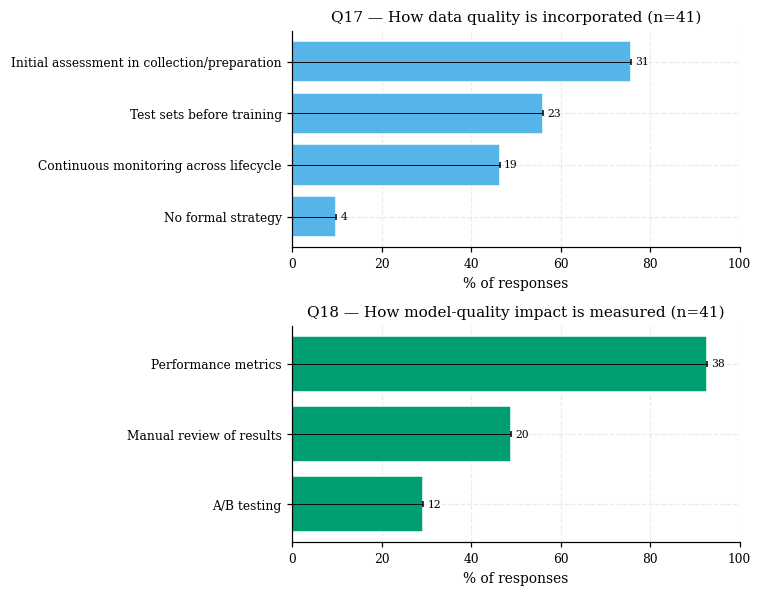

In [9]:
def horizontal_bar(p: pd.DataFrame, title: str, color: str, ax) -> None:
    p_sorted = p.sort_values("pct")
    y = np.arange(len(p_sorted))
    ax.barh(y, p_sorted["pct"], color=color, edgecolor="white")

    err_lo = np.clip(p_sorted["pct"] - p_sorted["ci_lo"], 0, None)
    err_hi = np.clip(p_sorted["ci_hi"] - p_sorted["pct"], 0, None)

    ax.errorbar(p_sorted["pct"], y,
                xerr=[err_lo, err_hi],
                fmt="none", ecolor="black", elinewidth=0.6, capsize=2)
    ax.set_yticks(y)
    ax.set_yticklabels(p_sorted["label"])
    ax.set_xlabel("% of responses")
    ax.set_xlim(0, 100)
    ax.set_title(title)
    for i, (pct, n) in enumerate(zip(p_sorted["pct"], p_sorted["n"])):
        ax.text(pct + 1, i, f"{int(n)}", va="center", fontsize=7)

fig, axes = plt.subplots(2, 1, figsize=(7.0, 5.5))
horizontal_bar(p17, f"Q17 — How data quality is incorporated (n={n_q17})", U.PALETTE_WONG[2], axes[0])
horizontal_bar(p18, f"Q18 — How model-quality impact is measured (n={n_q18})", U.PALETTE_WONG[3], axes[1])
fig.tight_layout()
U.save_fig(fig, "implementation_q17_q18")
plt.show()

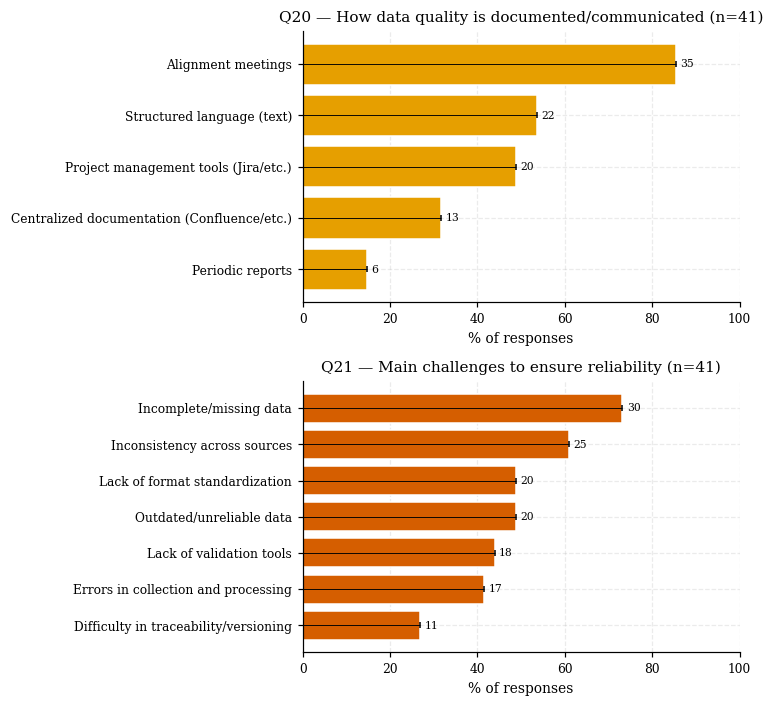

In [10]:
fig, axes = plt.subplots(2, 1, figsize=(7.0, 6.5))
horizontal_bar(p20, f"Q20 — How data quality is documented/communicated (n={n_q20})", U.PALETTE_WONG[1], axes[0])
horizontal_bar(p21, f"Q21 — Main challenges to ensure reliability (n={n_q21})", U.PALETTE_WONG[6], axes[1])
fig.tight_layout()
U.save_fig(fig, "challenges_q20_q21")
plt.show()

## 5. Consolidated LaTeX table (Q17/Q18/Q20/Q21)

In [11]:
def render_latex(p: pd.DataFrame, label: str, n: int) -> list[str]:
    header = "\\multicolumn{4}{l}{\\textit{" + label + f" (n={n})" + "}} \\\\"
    out = [header]
    for _, r in p.iterrows():
        out.append(f"\\quad {r['label']} & {int(r['n'])} & {r['pct']:.0f}\\% & [{r['ci_lo']:.0f}--{r['ci_hi']:.0f}] \\\\")
    return out

lines = [
    "\\begin{table}[t]",
    "\\caption{Practices for incorporation, measurement, documentation, and perceived challenges. Proportions with Wilson 95\\% CI.}",
    "\\label{tab:implementation}",
    "\\centering",
    "\\small",
    "\\begin{tabular}{lrrr}",
    "\\toprule",
    "\\textbf{Item} & \\textbf{n} & \\textbf{\\%} & \\textbf{IC 95\\%} \\\\",
    "\\midrule",
]
lines.extend(render_latex(p17, "Q17. Incorporation into development", n_q17))
lines.append("\\midrule")
lines.extend(render_latex(p18, "Q18. Measurement of model impact", n_q18))
lines.append("\\midrule")
lines.extend(render_latex(p20, "Q20. Documentation and communication", n_q20))
lines.append("\\midrule")
lines.extend(render_latex(p21, "Q21. Challenges to ensure reliability", n_q21))
lines.extend(["\\bottomrule", "\\end{tabular}", "\\end{table}"])
(TABLES / "implementation.tex").write_text("\n".join(lines))
print("[saved] tables/implementation.tex")

[saved] tables/implementation.tex


## 6. Q16 — anomaly as a meta-finding

30 out of 32 PT responses identical. The 2 divergent ones (P04 and P23) are semantically *wrong* alternatives: P04 says versioning *eliminates* documentation, P23 says it increases data *without* checking consistency. The pattern suggests a poorly designed instrument: a tendentiously correct option set as default + distractors rarely chosen. Reported in the paper as an instrument-validity finding, not as substantive evidence.

In [12]:
q16 = df["versioning_open"].value_counts(dropna=False)
print("=== Q16 response distribution ===")
for txt, n in q16.items():
    short = (txt[:80] + "...") if isinstance(txt, str) and len(txt) > 80 else txt
    print(f"  {n}× {short!r}")
print(f"\nDominant response proportion: {q16.iloc[0]/len(df)*100:.1f}% (n={q16.iloc[0]}/{len(df)})")

# Binomial test: is the dominant response compatible with uniform selection across 4 options?
# H0: dominant option has probability p_null = 1/4 (uniform draw)
# H1: probability > 1/4 (anomalous concentration)
from scipy.stats import binomtest
n_total = len(df)
k_dominant = int(q16.iloc[0])
n_options = 4  # Q16 has 4 options in the form
p_null = 1 / n_options
res = binomtest(k_dominant, n_total, p=p_null, alternative="greater")
ci = res.proportion_ci(confidence_level=0.95, method="wilson")
print()
print(f"=== Binomial test — Q16 ===")
print(f"H0: p_dominant = 1/{n_options} = {p_null:.3f} (uniform draw)")
print(f"Observed: {k_dominant}/{n_total} = {k_dominant/n_total:.3f}")
print(f"IC95% Wilson: [{ci.low:.3f}, {ci.high:.3f}]")
print(f"p-value (one-sided): {res.pvalue:.2e}")
print(f"-> Rejects H0 decisively: distribution incompatible with random selection.")
print(f"   Supports the pre-selected default-option hypothesis in Google Forms.")


=== Q16 response distribution ===
  30× 'Garante a consistência e rastreabilidade dos dados ao longo do tempo, permitindo...'
  7× 'Ensures data consistency and traceability over time, allowing changes to the dat...'
  1× 'Elimina a necessidade de documentar alterações no dataset, pois todas as mudança...'
  1× 'Aumenta a quantidade de dados disponíveis, sem necessidade de verificação de con...'
  1× 'I have no experience in this regard'
  1× 'Eliminates the need to document changes to the dataset, as all changes are autom...'

Dominant response proportion: 73.2% (n=30/41)

=== Binomial test — Q16 ===
H0: p_dominant = 1/4 = 0.250 (uniform draw)
Observed: 30/41 = 0.732
IC95% Wilson: [0.606, 1.000]
p-value (one-sided): 1.31e-10
-> Rejects H0 decisively: distribution incompatible with random selection.
   Supports the pre-selected default-option hypothesis in Google Forms.


## 7. Summary for Section 4 (plug-and-play text)

In [13]:
import json
summary_implementation = {
    "q17": {"n": int(n_q17), "items": p17.to_dict(orient="records")},
    "q18": {"n": int(n_q18), "items": p18.to_dict(orient="records")},
    "q20": {"n": int(n_q20), "items": p20.to_dict(orient="records")},
    "q21": {"n": int(n_q21), "items": p21.to_dict(orient="records")},
    "q16_anomaly": {
        "n_default": int(q16.iloc[0]),
        "n_total": int(len(df)),
        "pct_default": float(q16.iloc[0] / len(df) * 100),
        "interpretation": ("30 out of 32 identical responses indicate instrument failure — "
                            "default option not removed by the respondent. Reported in the paper as a "
                            "meta-finding about instrument validity, not as substantive evidence."),
    },
}
(TABLES / "implementation_summary.json").write_text(json.dumps(summary_implementation, ensure_ascii=False, indent=2))
print("[saved] tables/implementation_summary.json")

# Save binary frame for replication
all_bin = pd.concat([q17_bin, q18_bin, q20_bin, q21_bin], axis=1)
all_bin.to_csv(U.DATA_PROC / "checkboxes.csv", index_label="respondent_id")
print(f"[saved] data/processed/checkboxes.csv — {all_bin.shape}")

[saved] tables/implementation_summary.json
[saved] data/processed/checkboxes.csv — (41, 19)


## 8. Key findings for findings boxes

In [14]:
# Most and least adopted practices
print("--- Q17 incorporation ---")
print(f"  Most common: {p17.iloc[0]['label']} ({p17.iloc[0]['pct']:.0f}%)")
print(f"  No formal strategy: {p17[p17['key']=='q17_no_strategy']['pct'].iloc[0]:.0f}%")

print("--- Q18 measurement ---")
print(f"  Most common: {p18.iloc[0]['label']} ({p18.iloc[0]['pct']:.0f}%)")
print(f"  A/B testing: {p18[p18['key']=='q18_ab_tests']['pct'].iloc[0]:.0f}%")

print("--- Q20 documentation ---")
print(f"  Most common: {p20.iloc[0]['label']} ({p20.iloc[0]['pct']:.0f}%)")
print(f"  Periodic reports: {p20[p20['key']=='q20_periodic_reports']['pct'].iloc[0]:.0f}%")

print("--- Q21 challenges ---")
for _, r in p21.head(3).iterrows():
    print(f"  {r['label']}: {r['pct']:.0f}% (IC95 {r['ci_lo']:.0f}–{r['ci_hi']:.0f})")

--- Q17 incorporation ---
  Most common: Initial assessment in collection/preparation (76%)
  No formal strategy: 10%
--- Q18 measurement ---
  Most common: Performance metrics (93%)
  A/B testing: 29%
--- Q20 documentation ---
  Most common: Alignment meetings (85%)
  Periodic reports: 15%
--- Q21 challenges ---
  Incomplete/missing data: 73% (IC95 0–0)
  Inconsistency across sources: 61% (IC95 0–0)
  Lack of format standardization: 49% (IC95 0–0)


## 9. Fisher's exact — Q17/Q18/Q20/Q21 × demographic subgroups

For each binary marked item (presence/absence), tests association with:
- Seniors × Juniors
- Data scientists × Developers
- Men × Women

Why Fisher and not χ²: 2×2 tables with cells < 5 are common at N=41; Fisher's exact is exact under H0.

- Effect size: odds ratio (95% Wald CI on log-OR; continuity correction +0.5 when a cell is zero).
- Holm–Bonferroni within each family (question × comparison).


In [15]:
from statsmodels.stats.multitest import multipletests

# The binary dataframes (q17_bin etc) share the same index as df
binaries = [
    ("Q17", q17_bin, Q17_LABELS, df["incorporation_open"]),
    ("Q18", q18_bin, Q18_LABELS, df["measurement_open"]),
    ("Q20", q20_bin, Q20_LABELS, df["documentation_open"]),
    ("Q21", q21_bin, Q21_LABELS, df["challenges_open"]),
]

comparisons = [
    ("Seniors × Juniors", df["seniority_group"] == "senior", df["seniority_group"] == "junior"),
    ("Data scientists × Developers", df["role_group"] == "data_scientist", df["role_group"] == "developer"),
    ("Men × Women", df["gender_norm"] == "male", df["gender_norm"] == "female"),
]

rows = []
for q_name, bin_df, labels, source in binaries:
    answered = source.notna()
    for comp_name, mask_g1, mask_g2 in comparisons:
        m1 = answered & mask_g1
        m2 = answered & mask_g2
        if m1.sum() < 3 or m2.sum() < 3:
            continue
        for col in bin_df.columns:
            a = int(bin_df.loc[m1, col].sum())
            c = int(m1.sum() - a)
            b = int(bin_df.loc[m2, col].sum())
            d = int(m2.sum() - b)
            if (a + b) == 0 or (c + d) == 0:
                continue
            res = U.fisher_or_ci(a, b, c, d)
            rows.append({"question": q_name, "comparison": comp_name,
                         "item": labels.get(col, col),
                         "a": a, "b": b, "c": c, "d": d,
                         **res})

fisher_df = pd.DataFrame(rows)

# Holm within each (question, comparison)
fisher_df["p_holm"] = float("nan")
fisher_df["sig_holm"] = False
for (q, comp), grp in fisher_df.groupby(["question", "comparison"]):
    valid = grp["p"].notna()
    if valid.sum() == 0:
        continue
    reject, p_adj, _, _ = multipletests(grp.loc[valid, "p"], method="holm")
    idx = grp.loc[valid].index
    fisher_df.loc[idx, "p_holm"] = p_adj
    fisher_df.loc[idx, "sig_holm"] = reject
fisher_df["sig_raw"] = fisher_df["p"] < 0.05

print(f"Fisher: {len(fisher_df)} tests")
print(f"Significant (raw p<0.05): {fisher_df['sig_raw'].sum()}")
print(f"Significant after Holm:    {fisher_df['sig_holm'].sum()}")
print()
disp = ["question", "comparison", "item", "n1", "n2", "p1", "p2", "or", "or_lo", "or_hi", "p", "p_holm"]
print("Significant (raw):")
sig = fisher_df[fisher_df["sig_raw"]].sort_values("p")
if len(sig):
    print(sig[disp].to_string(index=False))
else:
    print("  (none)")

Fisher: 57 tests
Significant (raw p<0.05): 0
Significant after Holm:    0

Significant (raw):
  (none)


In [16]:
# Save full table for inspection
out = TABLES / "fisher_checkboxes.csv"
out.parent.mkdir(parents=True, exist_ok=True)
fisher_df.to_csv(out, index=False)
print(f"-> {out.relative_to(U.ROOT)} ({len(fisher_df)} rows)")


-> data\processed\tables\fisher_checkboxes.csv (57 rows)
